# Prac 06.1

This environment does not provide `dlib` on Python 3.13, so the notebook uses OpenCV's Haar cascade as a fully executable fallback for face detection.

In [1]:
import cv2
from pathlib import Path
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]
BASE = Path('..')
CASCADE_PATH = Path(cv2.data.haarcascades) / 'haarcascade_frontalface_default.xml'
face_detector = cv2.CascadeClassifier(str(CASCADE_PATH))
print('Cascade loaded:', not face_detector.empty())

Cascade loaded: True


### Step 1

Load an image that contains faces.

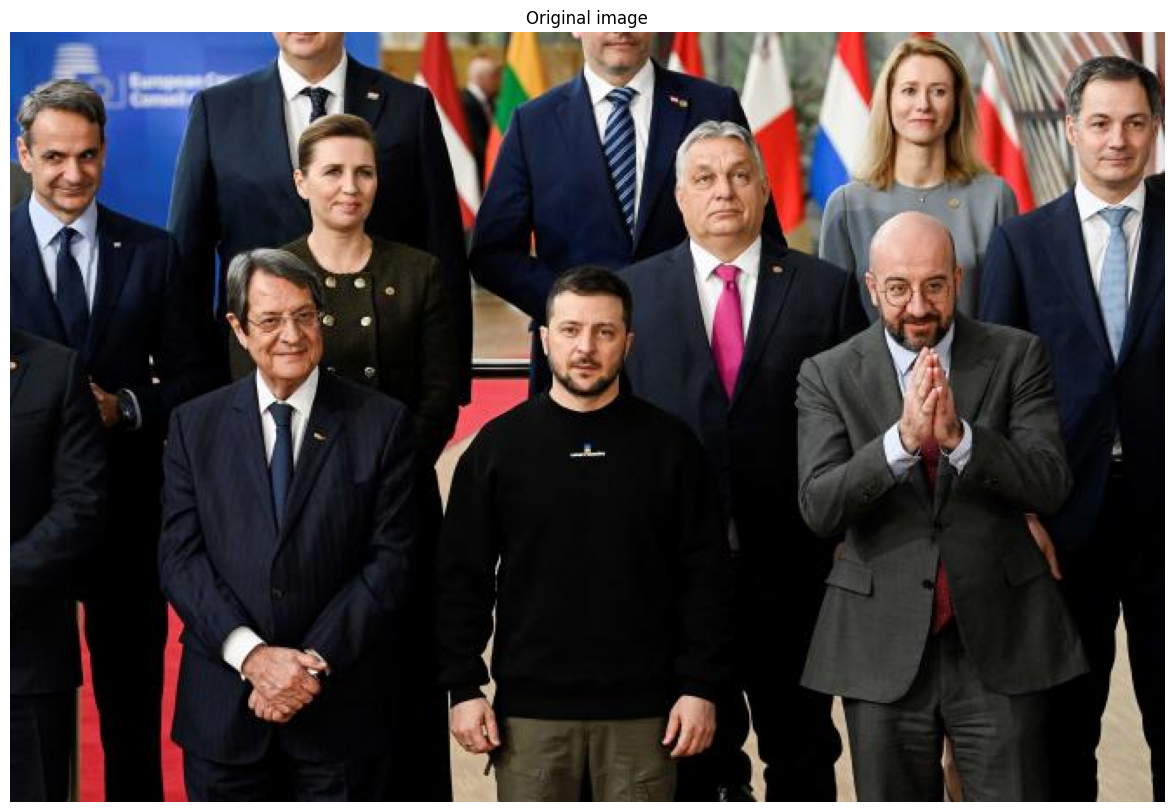

In [2]:
img_bgr = cv2.imread(str(BASE / 'data' / 'eu_summit.jpg'))
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img)
plt.title('Original image')
plt.axis('off')
plt.show()

### Step 2 and Step 3

Load the predictor and run it on the image.

In [3]:
faces = face_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
print('Detected faces:', len(faces))
faces[:5] if len(faces) else faces

Detected faces: 9


array([[501,  14,  49,  49],
       [167,  60,  54,  54],
       [303, 149,  57,  57],
       [609,  32,  52,  52],
       [129, 143,  56,  56]], dtype=int32)

### Step 4

Draw bounding boxes around the detected faces and plot the result.

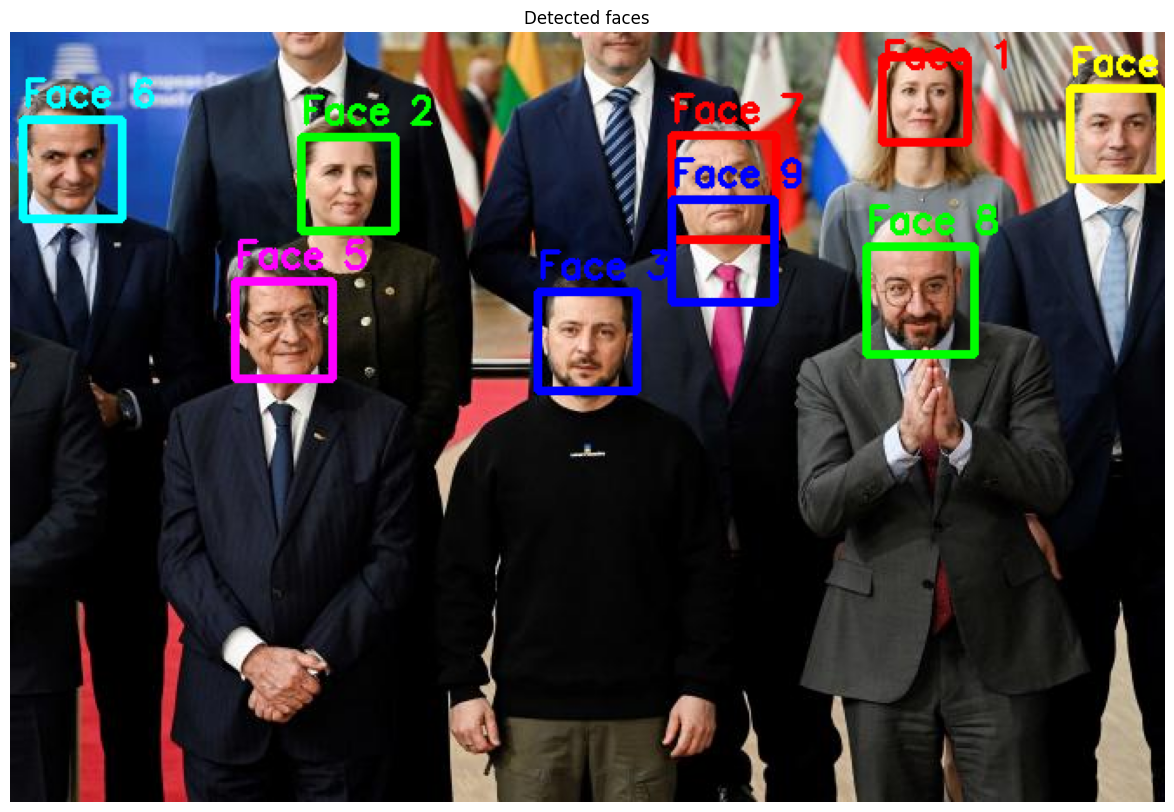

In [4]:
result = img.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]
for idx, (x, y, w, h) in enumerate(faces):
    color = colors[idx % len(colors)]
    cv2.rectangle(result, (x, y), (x + w, y + h), color, 3)
    cv2.putText(result, f'Face {idx + 1}', (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
plt.imshow(result)
plt.title('Detected faces')
plt.axis('off')
plt.show()

### Step 5

Repeat the process on a different image.

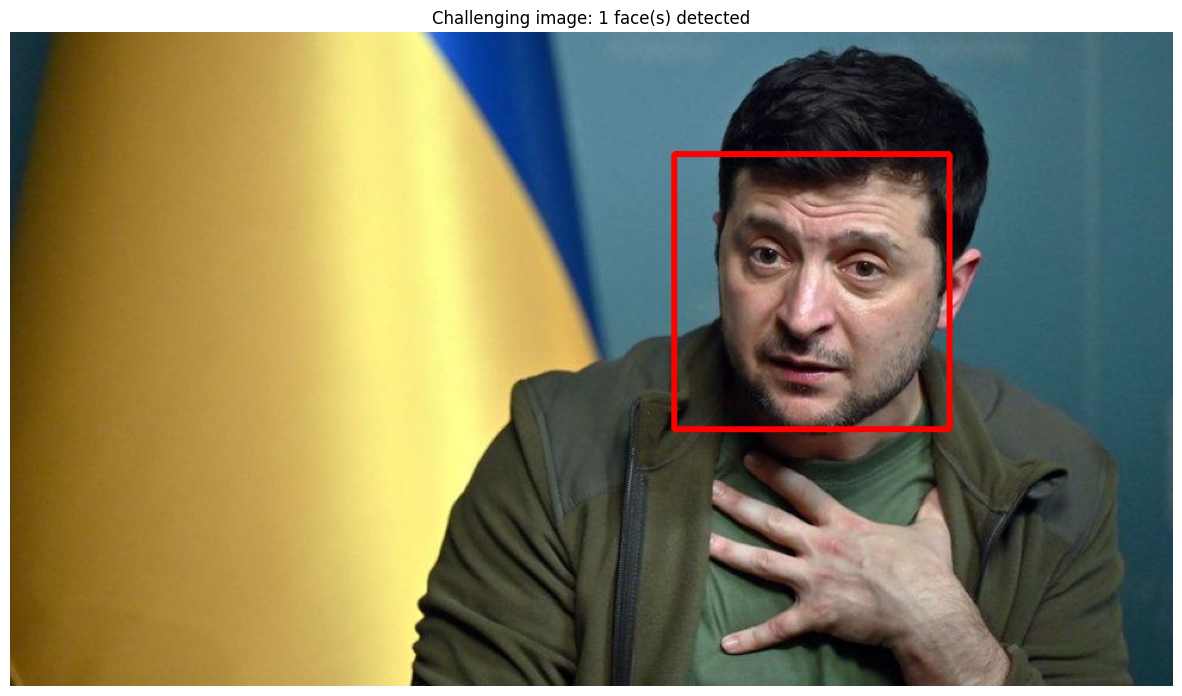

In [5]:
img2_bgr = cv2.imread(str(BASE / 'data' / 'zelensky.jpg'))
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
faces2 = face_detector.detectMultiScale(gray2, scaleFactor=1.1, minNeighbors=4, minSize=(25, 25))
result2 = img2.copy()
for idx, (x, y, w, h) in enumerate(faces2):
    color = colors[idx % len(colors)]
    cv2.rectangle(result2, (x, y), (x + w, y + h), color, 3)
plt.imshow(result2)
plt.title(f'Challenging image: {len(faces2)} face(s) detected')
plt.axis('off')
plt.show()

### Discussion

The detector works well for large frontal faces with good contrast. It becomes less reliable when the faces are small, rotated, or partially occluded, which is expected for a classical Haar-cascade approach.